In [1]:
import pandas as pd
import numpy as np
from NSGA2 import NSGA2_FS
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from IAMB import IAMB
from clustering import DBSCAN_Clustering
from Clumarpareto import CluMarPareto

In [2]:
def generate_dataset(n_samples, n_features, n_informative, n_redundant, n_repeated, n_classes):
    X, y = make_classification(
        n_samples = n_samples,
        n_features = n_features,
        n_informative = n_informative,   
        n_redundant = n_redundant,      
        n_repeated = n_repeated,
        n_classes = n_classes,
        random_state=42,
        shuffle = False
    )

    feature_cols = [f"feature_{i+1}" for i in range(X.shape[1])]
    df = pd.DataFrame(X, columns=feature_cols)
    df["target"] = y
    return df

## <h1>Observations and Results 
<h3>(Small data - low samples + low no of features)

In [3]:
data = generate_dataset(n_samples = 1000, n_features = 50, n_informative = 2, n_redundant = 2, n_repeated = 1, n_classes = 2)
data

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,...,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49,feature_50,target
0,-1.050478,-1.323568,0.912474,1.009796,0.912474,-0.154925,0.700736,-0.278391,0.633361,-1.540793,...,-0.858450,1.125588,-0.272975,-0.777539,0.728685,-0.488197,1.027422,-0.663720,-0.159595,0
1,-1.580834,-2.747104,1.777419,1.850430,1.777419,0.944972,-0.226261,0.756053,-0.065548,1.981692,...,-0.417964,1.274592,0.810062,1.075176,-1.368705,1.548000,-0.761408,0.192293,-0.148223,0
2,-0.885704,-0.614600,0.501004,0.631813,0.501004,-0.878483,-1.412536,-1.743848,0.119018,-1.525319,...,1.671483,-0.107559,-0.695044,-0.041169,0.537091,0.051626,-0.205728,-0.650017,-0.662131,0
3,-1.525438,-2.967793,1.884777,1.924410,1.884777,-0.597808,0.338815,-0.994180,0.393269,1.412995,...,0.331844,-0.423776,-1.617363,-0.716640,0.157055,0.162744,0.041379,0.548708,-0.581146,0
4,-1.076826,-1.014619,0.752233,0.885267,0.752233,0.026681,0.572093,-0.084890,-1.243324,-0.961488,...,0.406477,-1.579616,1.378710,-1.244831,-0.710081,-0.597710,-1.526271,0.032576,0.213904,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.792945,0.687195,-0.521841,-0.625632,-0.521841,0.519147,-1.884094,1.280781,0.874839,-0.356611,...,-0.240889,0.142886,0.298590,1.090375,0.778570,0.951085,-0.352021,0.287708,1.734886,1
996,1.063154,0.887385,-0.681478,-0.823942,-0.681478,-0.096858,0.129330,0.142710,-0.103958,1.288156,...,-0.537584,0.544619,1.088981,1.980982,-1.864282,-1.027763,-0.342131,0.556130,0.764410,1
997,0.244362,0.231442,-0.171343,-0.201416,-0.171343,-1.178801,0.376374,-2.559875,0.291922,-0.026137,...,1.784793,-0.364092,-1.261689,-1.190092,1.036209,-1.686562,0.063828,-0.176226,-0.675419,1
998,1.777667,1.742310,-1.277857,-1.490927,-1.277857,-0.858359,0.696159,0.777406,1.167324,0.484341,...,-0.136359,0.314154,-0.121295,-0.205613,-0.492848,-1.889007,1.767494,0.197976,-0.081504,0


In [6]:
nsga = NSGA2_FS(classifier = 'decisiontree', population_size = 200)
nsga.fit(data)


Classifier      : decisiontree
Population size : 200
Number of fronts: 35

  Gen  10 | Pareto size:   8 | Best acc: 0.9090 | Min features: 8
  Gen  20 | Pareto size:  12 | Best acc: 0.9140 | Min features: 5
  Gen  30 | Pareto size:  12 | Best acc: 0.9140 | Min features: 2
  Gen  40 | Pareto size: 200 | Best acc: 0.9150 | Min features: 1
  Gen  50 | Pareto size: 200 | Best acc: 0.9150 | Min features: 1
  Gen  60 | Pareto size: 200 | Best acc: 0.9150 | Min features: 1
  Gen  70 | Pareto size: 200 | Best acc: 0.9150 | Min features: 1
  Gen  80 | Pareto size: 200 | Best acc: 0.9150 | Min features: 1
  Gen  90 | Pareto size: 200 | Best acc: 0.9150 | Min features: 1
  Gen 100 | Pareto size: 200 | Best acc: 0.9150 | Min features: 1

Final Pareto Front (200 solutions):
 Features_selected   Features   Accuracy
  ----------------------
 [False  True False False False False False False False False False False
 False False False False False False False False False False False False
 False False F

In [7]:
sol = nsga.find_knee_point(nsga.pareto_front_)
print(sol.mask_features, sol.obj_scores[0], sol.obj_scores[1])

[ True  True False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False] 2 0.9029999999999999


<b>NSGA 2 Alone takes a average time of 6 mins for a dataset with 50 features, 1000 samples and for 200 generations

In [4]:
X_train, X_test = train_test_split(data, test_size=0.2, random_state=42)

eps calculated through elbow curve:  0.9018006195075979


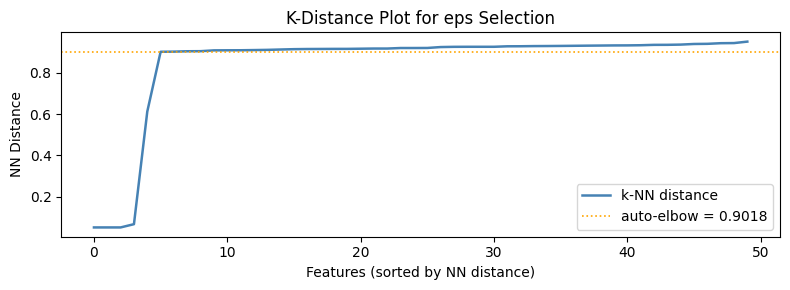

Clusters found : 6
Noise features : 33  (66.0%)
eps increased to:  0.951800619507598
Clusters found : 1
Noise features : 0  (0.0%)
eps decreased to  0.926800619507598
Clusters found : 3
Noise features : 5  (10.0%)

Cluster assignments:
  Cluster 0: ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_20', 'feature_21', 'feature_22', 'feature_23', 'feature_24', 'feature_25', 'feature_26', 'feature_27', 'feature_29', 'feature_30', 'feature_31', 'feature_32', 'feature_33', 'feature_34', 'feature_35', 'feature_38', 'feature_39', 'feature_40', 'feature_41', 'feature_42', 'feature_43', 'feature_44', 'feature_46', 'feature_48', 'feature_50']
  Cluster 1: ['feature_37', 'feature_49']
  Cluster 2: ['feature_45', 'feature_47']
  Noise features: ['feature_11', 'feature_18', 'feature_19', 'feature_28', 'feature_36']

[IAMB] Clus

In [5]:
feature_cols = data.columns[:-1]
model = DBSCAN_Clustering()
model.build_distance_matrix(X_train.iloc[:,:-1].values)          
model.cluster_features(feature_names=feature_cols)

print("\nCluster assignments:")
for cid, idxs in model.clusters.items():
    names = [feature_cols[i] for i in idxs]
    print(f"  Cluster {cid}: {names}")
if model.noise:
    noise_names = [feature_cols[i] for i in model.noise]
    print(f"  Noise features: {noise_names}")

# X_train, X_test, y_train, y_test = train_test_split(data.iloc[:,:-1].values, data.iloc[:,-1].values, test_size=0.2, random_state=42)

iamb = IAMB(alpha=0.01, n_bins=5)
selected = iamb.run(model.clusters, X_train.iloc[:,:-1].values,X_train.iloc[:,-1].values)
selected += model.noise
selected_feature_names=[feature_cols[i] for i in selected]
print("\nSelected from clusters:", selected)
print("Selected feature names:", selected_feature_names)
print("length of selected features: ",len(selected_feature_names))

In [6]:
data = data[selected_feature_names+['target']]
nsga = NSGA2_FS(classifier = 'decisiontree', population_size = 200)
nsga.fit(data)


Classifier      : decisiontree
Population size : 200
Number of fronts: 33

  Gen  10 | Pareto size:   2 | Best acc: 0.9120 | Min features: 6
  Gen  20 | Pareto size:  27 | Best acc: 0.9140 | Min features: 3
  Gen  30 | Pareto size: 200 | Best acc: 0.9150 | Min features: 2
  Gen  40 | Pareto size: 200 | Best acc: 0.9150 | Min features: 1
  Gen  50 | Pareto size: 200 | Best acc: 0.9150 | Min features: 1
  Gen  60 | Pareto size: 200 | Best acc: 0.9150 | Min features: 1
  Gen  70 | Pareto size: 200 | Best acc: 0.9150 | Min features: 1
  Gen  80 | Pareto size: 200 | Best acc: 0.9150 | Min features: 1
  Gen  90 | Pareto size: 200 | Best acc: 0.9150 | Min features: 1
  Gen 100 | Pareto size: 200 | Best acc: 0.9150 | Min features: 1

Final Pareto Front (200 solutions):
 Features_selected   Features   Accuracy
  ----------------------
 [ True False False False False False False False False False False False
 False False False False False False False False False False False False
 False False F

In [7]:
sol = nsga.find_knee_point(nsga.pareto_front_)
print(sol.mask_features, sol.obj_scores[0], sol.obj_scores[1])

[ True  True False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False] 2 0.9019999999999999


STAGE 1 — DBSCAN Clustering
eps calculated through elbow curve:  0.9024516763645154


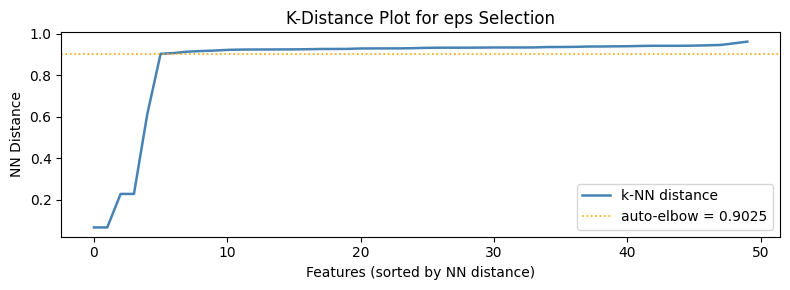

Clusters found : 2
Noise features : 41  (82.0%)
eps increased to:  0.9524516763645154
Clusters found : 1
Noise features : 0  (0.0%)
eps decreased to  0.9274516763645154
Clusters found : 1
Noise features : 9  (18.0%)
eps decreased to  0.9149516763645155
Clusters found : 4
Noise features : 23  (46.0%)

STAGE 2 — IAMB within clusters

[IAMB] Cluster 0 — features [0, 1, 2, 3, 4, 6, 7, 15, 16, 19, 21, 24, 26, 33, 40, 49]
[0, 1, 2, 3, 4, 6, 7, 15, 16, 19, 21, 24, 26, 33, 40, 49]
Forward phase added feature 1  CMI=0.3580
Forward phase added feature 0  CMI=0.1122
Forward phase added feature 3  CMI=0.0246
Forward phase added feature 4  CMI=0.0228
Forward phase added feature 7  CMI=0.0178
Forward phase added feature 10  CMI=0.0107
Backward phase removed feature 3  CMI=0.0000
  → Selected: [1, 0, 4, 15, 21]

[IAMB] Cluster 1 — features [8, 12, 14, 41]
[8, 12, 14, 41]
Forward phase added feature 0  CMI=0.0188
Forward phase added feature 3  CMI=0.0159
Forward phase added feature 1  CMI=0.0474
Forwa

/Users/lalithkishoresridhar/GitHub/venv/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  Gen  60 | Pareto size:  11 | Best acc: 0.9125 | Min features: 1


/Users/lalithkishoresridhar/GitHub/venv/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  Gen  70 | Pareto size:  12 | Best acc: 0.9125 | Min features: 1


...

  Gen  80 | Pareto size:  12 | Best acc: 0.9125 | Min features: 1


/Users/lalithkishoresridhar/GitHub/venv/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  Gen  90 | Pareto size:  12 | Best acc: 0.9125 | Min features: 1


/Users/lalithkishoresridhar/GitHub/venv/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  Gen 100 | Pareto size:  13 | Best acc: 0.9125 | Min features: 1

Final Pareto Front (13 solutions):
 Features_selected   Features   Accuracy
  ----------------------
 [ True False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False]          1     0.8550
 [ True  True False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False]          2     0.9037
 [ True  True  True False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False]          3     0.9075
 [ True  True  True False False False False False False False False False
 False  True False False Fals

In [5]:

pipeline = CluMarPareto(classifier='decisiontree')
pipeline.fit(data = X_train)

In [6]:
masks = [tuple(ind.mask_features) for ind in pipeline.nsga2_.pareto_front_]
print("Total Pareto points:  ", len(masks))
print("Unique masks:         ", len(set(masks)))

Total Pareto points:   4
Unique masks:          4
